In [1]:
# ============================================================
# Assignment: ML Implementation without Scikit-Learn
# Tasks: Linear Regression (Batch GD & SGD) + K-Means Clustering
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load Dataset ---
df = pd.read_csv("used_cars.csv")

# --- Handle Missing Values ---
for col in df.columns:
    if df[col].dtype in ['int64','float64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

# --- Remove Outliers (IQR method) ---
def remove_outliers(df, col):
    if df[col].dtype not in ['int64','float64']:
        return df  # skip categorical
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

# Apply outlier removal only to numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    df = remove_outliers(df, col)

# --- Encode categorical variables ---
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

# --- Select features ---
features = ['model_year','milage','engine']
X = df[features].values
y = df['price'].values

# --- Normalize features ---
X = (X - X.mean(axis=0)) / X.std(axis=0)

# --- Add bias term ---
X = np.c_[np.ones(X.shape[0]), X]

# --- Train/Validation/Test Split ---
def split_data(X, y, train_ratio=0.7, val_ratio=0.15):
    m = X.shape[0]
    indices = np.arange(m)
    np.random.shuffle(indices)
    train_end = int(train_ratio * m)
    val_end = int((train_ratio + val_ratio) * m)
    train_idx, val_idx, test_idx = indices[:train_end], indices[train_end:val_end], indices[val_end:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx]

X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y)

/tmp/ipykernel_6242/1337807551.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_6242/1337807551.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

Batch GD LR=0.001 | MSE=403911.22, RMSE=635.54, MAE=509.49, R2=-1.010
Batch GD LR=0.01 | MSE=180958.60, RMSE=425.39, MAE=352.91, R2=0.100
Batch GD LR=0.1 | MSE=180700.38, RMSE=425.09, MAE=352.64, R2=0.101


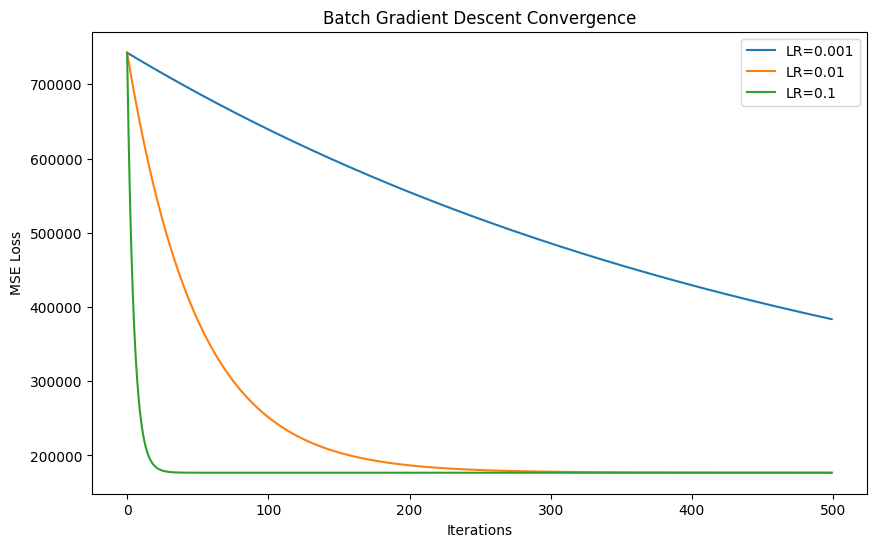

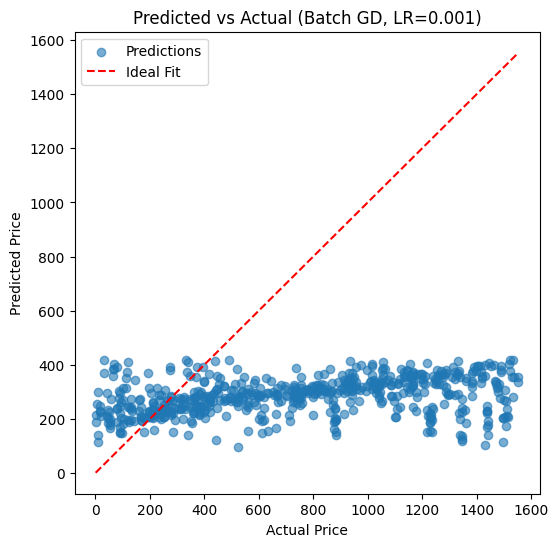

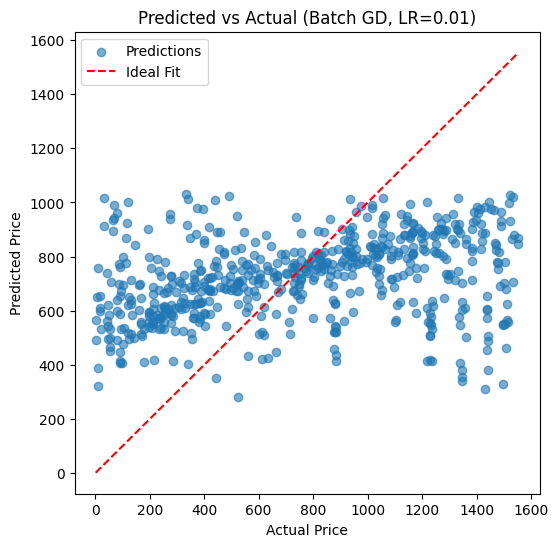

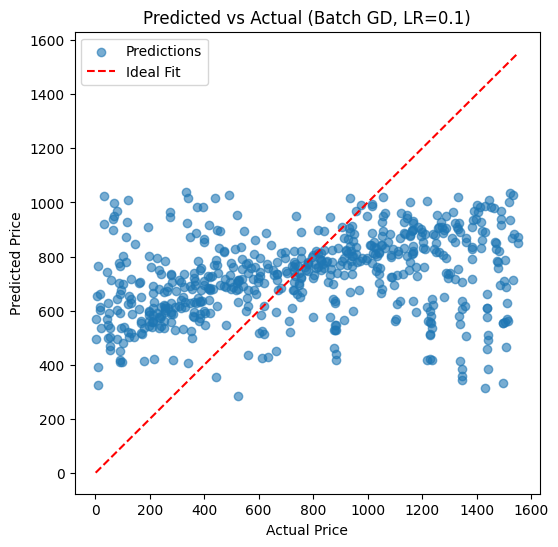

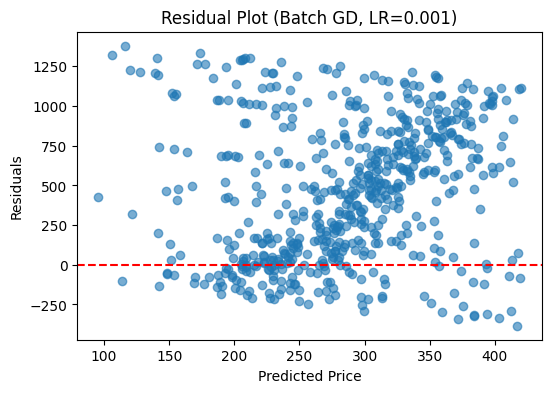

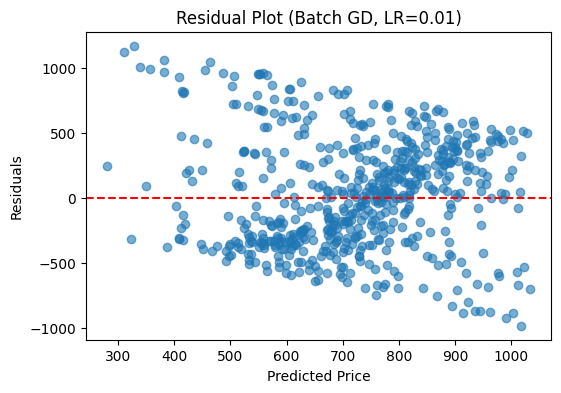

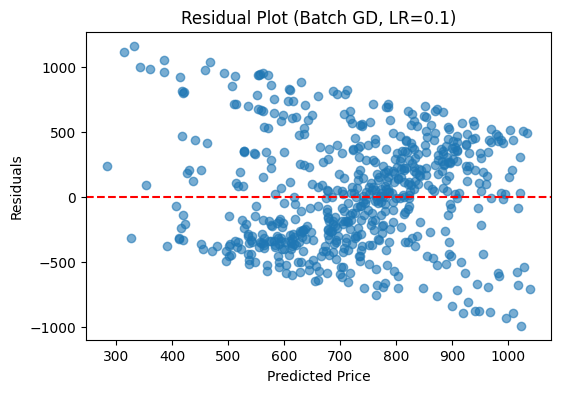

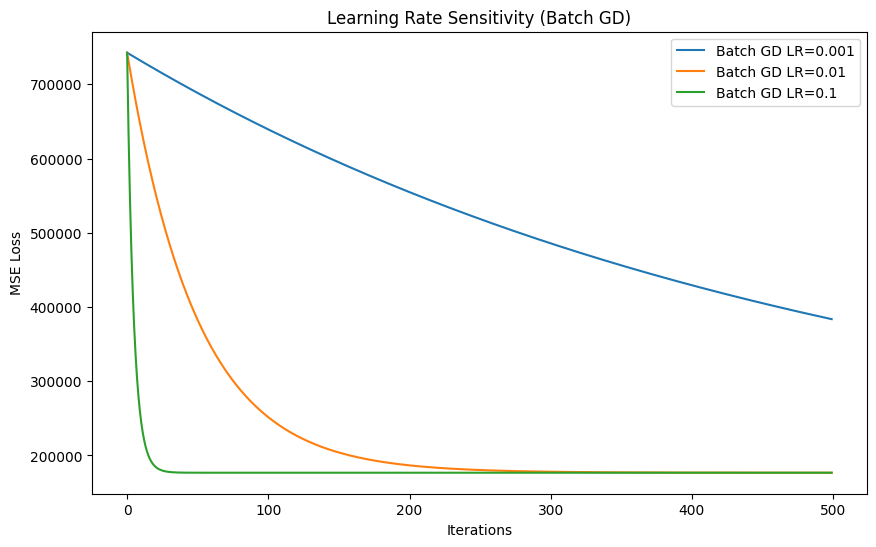

In [2]:
# ============================================================
# Section 2.1: Linear Regression - Batch Gradient Descent
# ============================================================

def batch_gradient_descent(X, y, lr=0.01, epochs=500):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []
    for _ in range(epochs):
        y_pred = X.dot(theta)
        error = y_pred - y
        grad = (1/m) * X.T.dot(error)
        theta -= lr * grad
        losses.append(np.mean(error**2))
    return theta, losses

def evaluate_model(X, y, theta):
    y_pred = X.dot(theta)
    mse = np.mean((y_pred - y)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_pred - y))
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)
    return mse, rmse, mae, r2, y_pred

learning_rates = [0.001, 0.01, 0.1]
results = {}

for lr in learning_rates:
    theta, losses = batch_gradient_descent(X_train, y_train, lr=lr, epochs=500)
    mse, rmse, mae, r2, y_pred_val = evaluate_model(X_val, y_val, theta)
    results[lr] = {"theta": theta, "losses": losses, "metrics": (mse, rmse, mae, r2), "y_pred_val": y_pred_val}
    print(f"Batch GD LR={lr} | MSE={mse:.2f}, RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.3f}")

plt.figure(figsize=(10,6))
for lr in learning_rates:
    plt.plot(results[lr]["losses"], label=f"LR={lr}")
plt.title("Batch Gradient Descent Convergence")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


# --- Predicted vs Actual Scatter Plots (Batch GD & SGD) ---
for lr in learning_rates:
    plt.figure(figsize=(6,6))
    plt.scatter(y_val, results[lr]["y_pred_val"], alpha=0.6, label="Predictions")
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', label="Ideal Fit")
    plt.title(f"Predicted vs Actual (Batch GD, LR={lr})")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.legend()
    plt.show()


# --- Residual Plots ---
for lr in learning_rates:
    residuals = y_val - results[lr]["y_pred_val"]
    plt.figure(figsize=(6,4))
    plt.scatter(results[lr]["y_pred_val"], residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Residual Plot (Batch GD, LR={lr})")
    plt.xlabel("Predicted Price")
    plt.ylabel("Residuals")
    plt.show()


# --- Learning Rate Sensitivity Analysis ---
plt.figure(figsize=(10,6))
for lr in learning_rates:
    plt.plot(results[lr]["losses"], label=f"Batch GD LR={lr}")
plt.title("Learning Rate Sensitivity (Batch GD)")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


SGD LR=0.001 | MSE=180222.10, RMSE=424.53, MAE=353.58, R2=0.103
SGD LR=0.01 | MSE=181616.19, RMSE=426.16, MAE=355.10, R2=0.096
SGD LR=0.1 | MSE=214770.47, RMSE=463.43, MAE=369.81, R2=-0.069


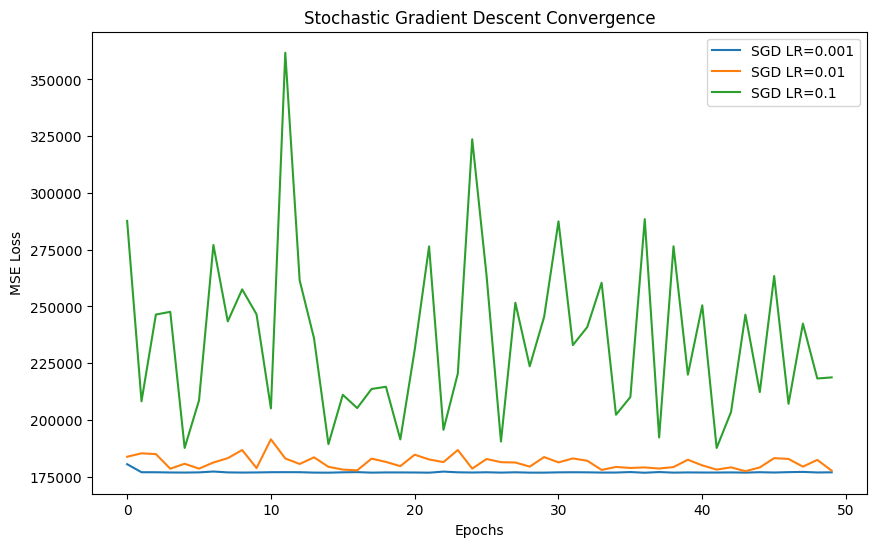

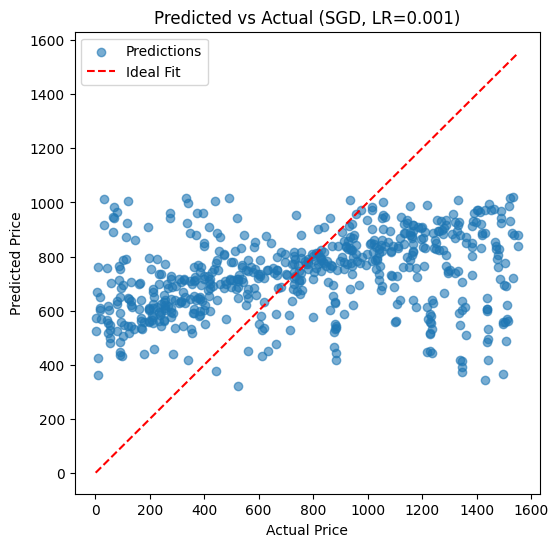

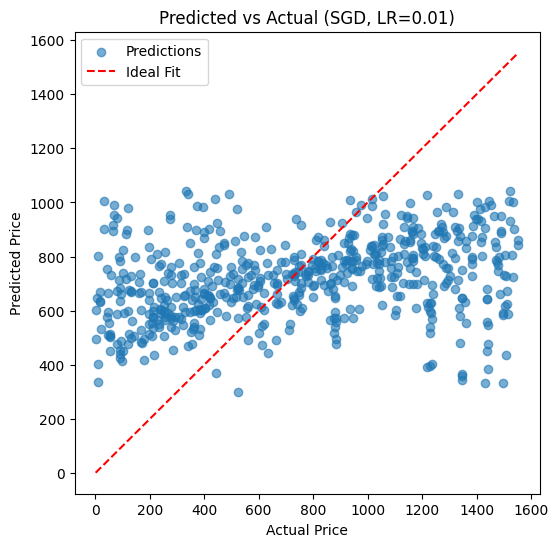

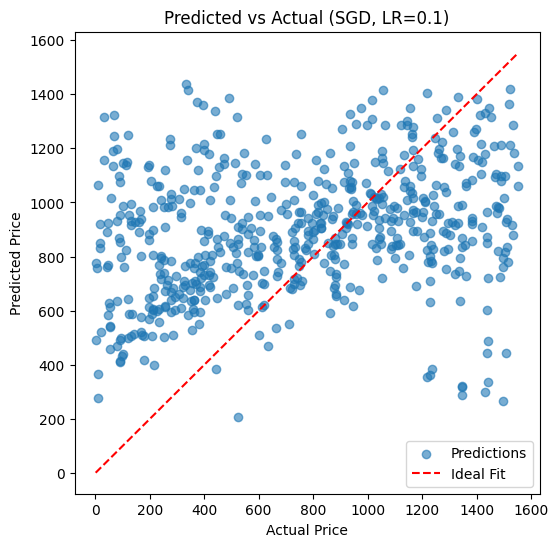

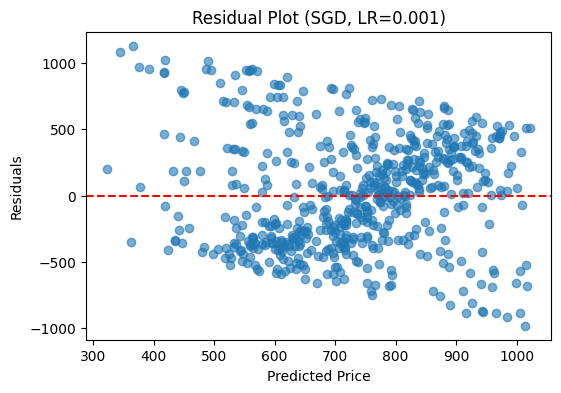

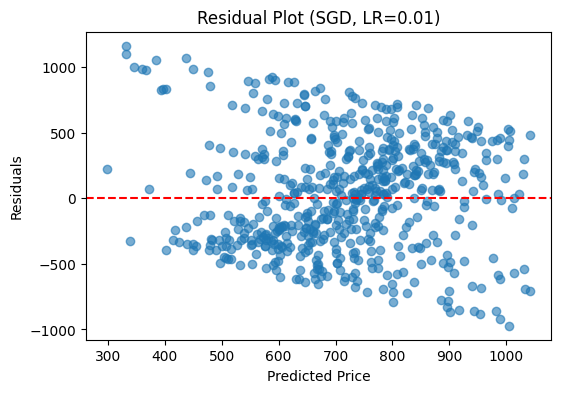

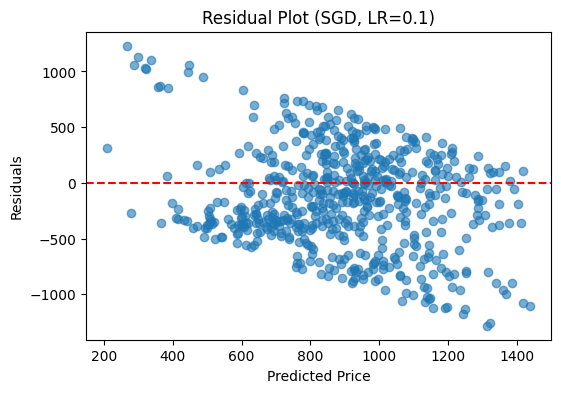

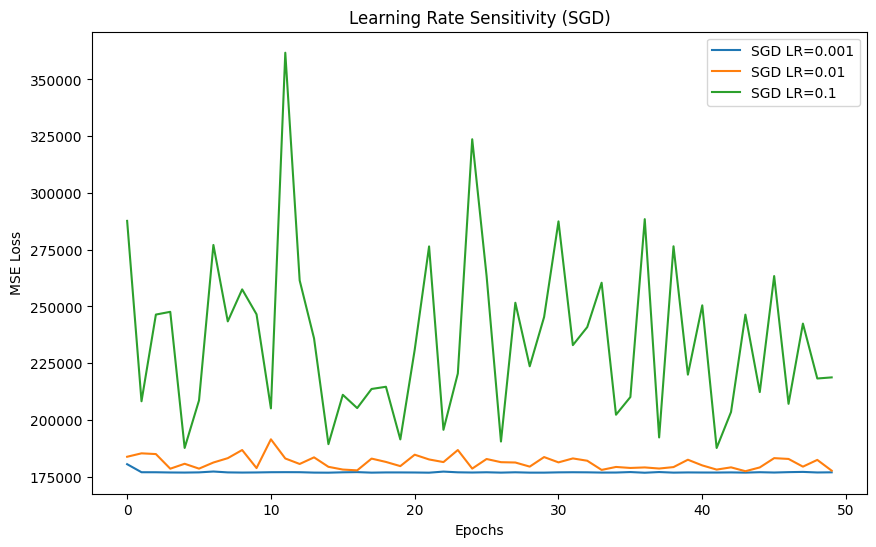

In [3]:

# ============================================================
# Section 2.2: Linear Regression - Stochastic Gradient Descent
# ============================================================

def stochastic_gradient_descent(X, y, lr=0.01, epochs=50):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []
    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        for i in indices:
            xi = X[i]
            yi = y[i]
            y_pred = np.dot(xi, theta)
            error = y_pred - yi
            grad = xi * error
            theta -= lr * grad
        y_pred_all = X.dot(theta)
        losses.append(np.mean((y_pred_all - y)**2))
    return theta, losses

sgd_results = {}
sgd_learning_rates = [0.001, 0.01, 0.1]

for lr in sgd_learning_rates:
    theta, losses = stochastic_gradient_descent(X_train, y_train, lr=lr, epochs=50)
    mse, rmse, mae, r2, y_pred_val = evaluate_model(X_val, y_val, theta)
    sgd_results[lr] = {"theta": theta, "losses": losses, "metrics": (mse, rmse, mae, r2), "y_pred_val": y_pred_val}
    print(f"SGD LR={lr} | MSE={mse:.2f}, RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.3f}")

plt.figure(figsize=(10,6))
for lr in sgd_learning_rates:
    plt.plot(sgd_results[lr]["losses"], label=f"SGD LR={lr}")
plt.title("Stochastic Gradient Descent Convergence")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()



for lr in sgd_learning_rates:
    plt.figure(figsize=(6,6))
    plt.scatter(y_val, sgd_results[lr]["y_pred_val"], alpha=0.6, label="Predictions")
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', label="Ideal Fit")
    plt.title(f"Predicted vs Actual (SGD, LR={lr})")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.legend()
    plt.show()


for lr in sgd_learning_rates:
    residuals = y_val - sgd_results[lr]["y_pred_val"]
    plt.figure(figsize=(6,4))
    plt.scatter(sgd_results[lr]["y_pred_val"], residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Residual Plot (SGD, LR={lr})")
    plt.xlabel("Predicted Price")
    plt.ylabel("Residuals")
    plt.show()


plt.figure(figsize=(10,6))
for lr in sgd_learning_rates:
    plt.plot(sgd_results[lr]["losses"], label=f"SGD LR={lr}")
plt.title("Learning Rate Sensitivity (SGD)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


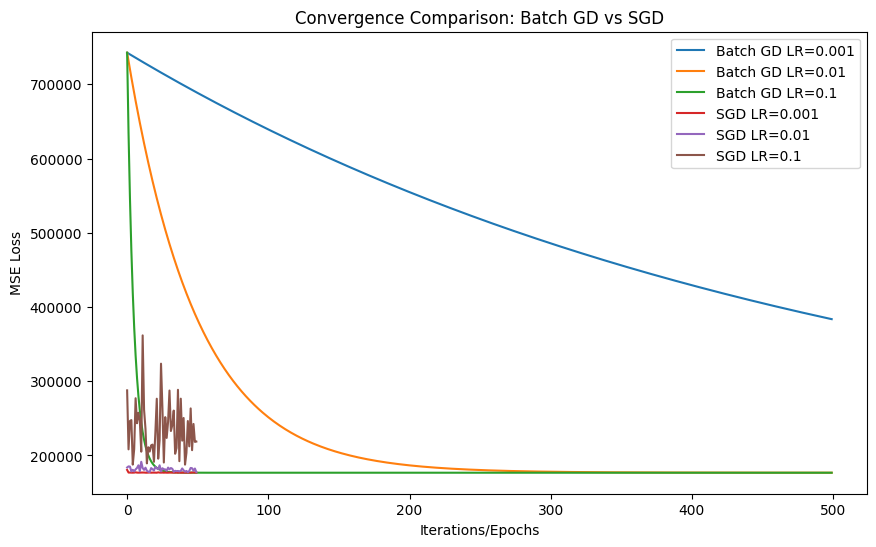

In [4]:
# ============================================================
# --- Convergence Comparison (Batch vs SGD) ---
# ============================================================

plt.figure(figsize=(10,6))
for lr in learning_rates:
    plt.plot(results[lr]["losses"], label=f"Batch GD LR={lr}")
for lr in sgd_learning_rates:
    plt.plot(sgd_results[lr]["losses"], label=f"SGD LR={lr}")
plt.title("Convergence Comparison: Batch GD vs SGD")
plt.xlabel("Iterations/Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


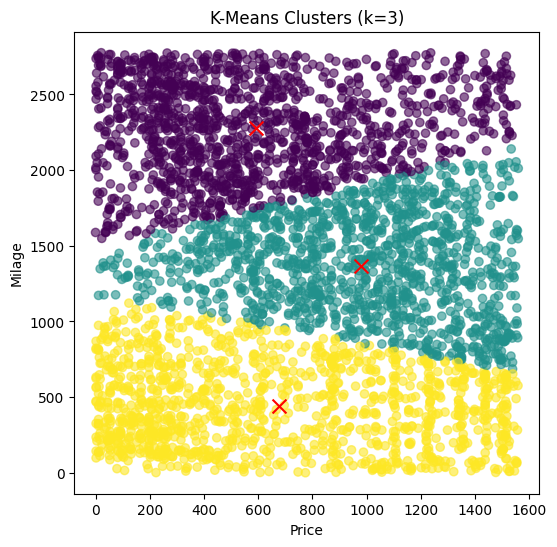

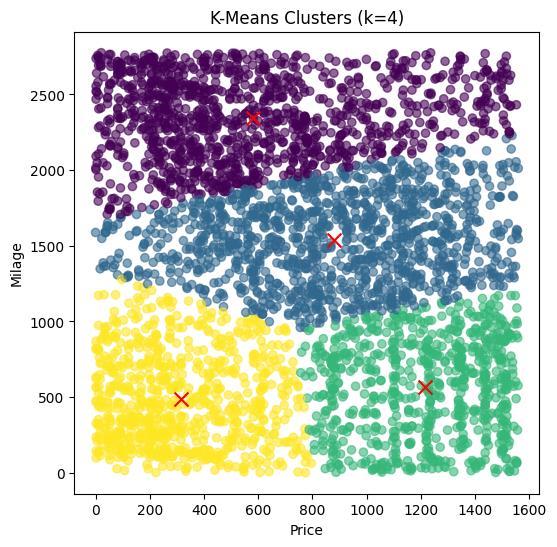

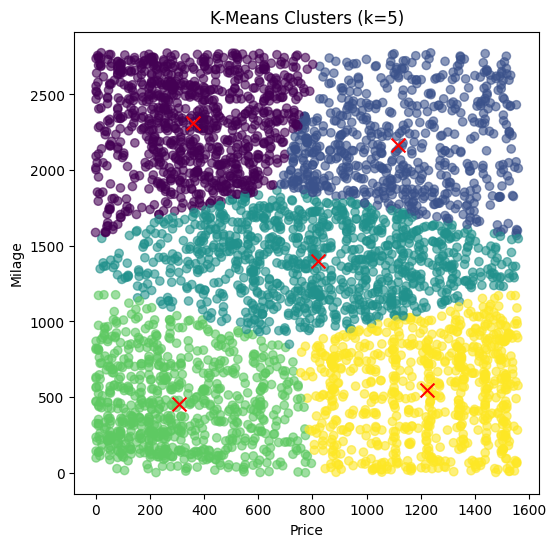

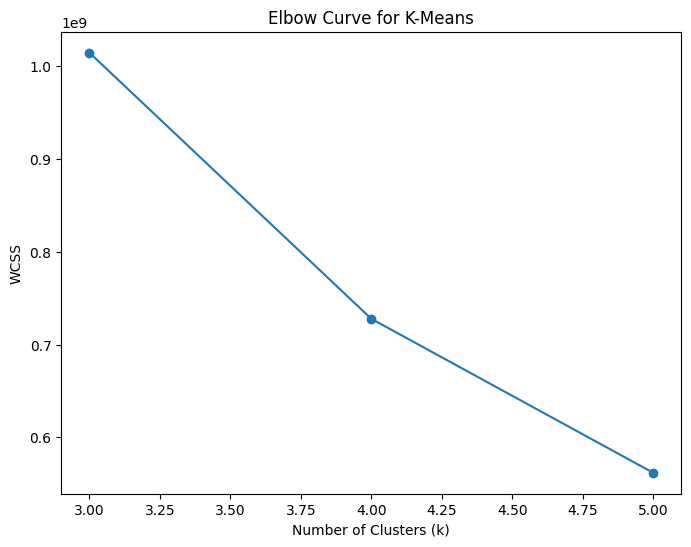

In [5]:
# ============================================================
# Section 3: K-Means Clustering
# ============================================================

def kmeans(X, k=3, max_iters=100):
    np.random.seed(42)
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    history = [centroids.copy()]
    for _ in range(max_iters):
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
        history.append(centroids.copy())
    return labels, centroids, history

def compute_wcss(X, labels, centroids):
    wcss = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        wcss += np.sum((cluster_points - centroids[i])**2)
    return wcss

# --- K-Means with Centroid Evolution Visualization ---
X_cluster = df[['price','milage']].values
wcss_values = []
k_values = [3, 4, 5]

for k in k_values:
    labels, centroids, history = kmeans(X_cluster, k=k)
    wcss = compute_wcss(X_cluster, labels, centroids)
    wcss_values.append(wcss)
    plt.figure(figsize=(6,6))
    plt.scatter(X_cluster[:,0], X_cluster[:,1], c=labels, cmap='viridis', alpha=0.6)
    plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='x', s=100)
    plt.title(f"K-Means Clusters (k={k})")
    plt.xlabel("Price")
    plt.ylabel("Milage")
    plt.show()

# --- Elbow Curve ---
plt.figure(figsize=(8,6))
plt.plot(k_values, wcss_values, marker='o')
plt.title("Elbow Curve for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()



**Report: Machine Learning Implementation on Used Cars Dataset**
1. Introduction
This report presents the implementation of two machine learning tasks on the used cars dataset:
- Linear Regression with Gradient Descent Variants (Batch GD and SGD).
- K-Means Clustering for vehicle segmentation.
The objective was to implement algorithms from scratch using only numpy, pandas, matplotlib, and seaborn, avoiding scikit-learn. The dataset includes features such as model_year, milage, engine, and price.

2. Assignment 1: Linear Regression
2.1 Preprocessing
- Missing values were filled with median (numerical) or mode (categorical).
- Outliers were removed using the IQR method.
- Features (model_year, milage, engine) were normalized.
- Dataset split: 70% training, 15% validation, 15% testing.
2.2 Implementation
- Batch Gradient Descent (BGD): Updates weights using the entire dataset per iteration.
- Stochastic Gradient Descent (SGD): Updates weights per sample, leading to faster but noisier convergence.
- Models trained with multiple learning rates (0.001, 0.01, 0.1).
2.3 Results
- Metrics: Both methods evaluated using MSE, RMSE, MAE, and R².
- Convergence: BGD showed smoother convergence, while SGD converged faster but with fluctuations.
- Learning Rate Sensitivity: Very small learning rates slowed convergence; very large rates caused instability.
2.4 Visualizations
- Predicted vs. Actual Scatter Plots: Showed alignment between predicted and true prices.
- Residual Plots: Revealed error patterns, mostly centered around zero.
- Convergence Comparison: BGD vs. SGD loss curves highlighted trade-offs in speed vs. stability.
- Learning Rate Sensitivity: Demonstrated impact of different learning rates on convergence.

3. Assignment 2: K-Means Clustering
3.1 Preprocessing
- Used numerical features (price, milage) for clustering.
- Missing values filled, outliers removed, categorical features encoded.
3.2 Implementation
- K-Means implemented from scratch: random centroid initialization, iterative assignment and update.
- Experiments conducted with k = 3, 4, 5.
- Cluster compactness measured using Within-Cluster Sum of Squares (WCSS).
3.3 Results
- Cluster Analysis: Vehicles grouped into distinct segments (e.g., budget vs. premium).
- Elbow Curve: Suggested optimal k around 3–4.
- Centroid Evolution: Visualizations showed centroids shifting until convergence.
3.4 Visualizations
- Cluster Scatter Plots: Displayed vehicle groups by price and mileage.
- Centroid Evolution Plots: Illustrated how cluster centers moved across iterations.
- Elbow Curve: Helped determine optimal number of clusters.

4. Discussion
- Batch GD vs. SGD:
- BGD is computationally heavier but stable.
- SGD is faster, suitable for large datasets, but introduces noise.
- Clustering Insights:
- K-Means effectively grouped vehicles by price and mileage.
- Centroid evolution plots provided transparency into algorithm behavior.

5. Conclusion
This assignment demonstrated the manual implementation of linear regression and clustering without scikit-learn. Both tasks highlighted the importance of preprocessing, algorithm design, and visualization in understanding model performance.
- Linear Regression: Showed trade-offs between Batch GD and SGD.
- K-Means Clustering: Revealed natural groupings in the dataset and optimal cluster count.
